In [1]:
import math
import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import timm
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [2]:
cudaStatus = torch.cuda.is_available()
device = torch.device("cuda" if cudaStatus else "cpu")
print(f"Using device: {device}")
print(f"device name: {torch.cuda.get_device_name(0) if cudaStatus else 'CPU'}")

Using device: cuda
device name: Tesla T4


In [3]:
randSeed = 42
torch.manual_seed(randSeed)
if cudaStatus:
    torch.cuda.manual_seed_all(randSeed)
np.random.seed(randSeed)

In [4]:
TrainCSV = pd.read_csv("/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/train.csv")
TestCSV = pd.read_csv("/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/test.csv")

Labels = [col for col in TrainCSV.columns if col != "id"]
imgPath = "/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/images"
TrainCSV["ImgPath"] = TrainCSV["id"].apply(lambda image_id: f"{imgPath}/{image_id}")
TestCSV["ImgPath"] = TestCSV["id"].apply(lambda image_id: f"{imgPath}/{image_id}")
TrainCSV["label"] = TrainCSV[Labels].to_numpy().argmax(axis=1).astype(np.int64)

print(f"Labels: {len(Labels):,} classes")
TrainCSV["label"].head()

Labels: 20 classes


0    19
1    19
2     0
3    19
4    19
Name: label, dtype: int64

In [5]:
img = Image.open(TrainCSV["ImgPath"].iloc[0])
print(f"Image size: {img.size}")
print(f"Stored mode: {img.mode}")

Image size: (384, 384)
Stored mode: RGB


In [6]:
ClassDist = TrainCSV[Labels].sum(axis=0)
ClassDist

Atelectasis                    2351
Cardiomegaly                    600
Consolidation                   651
Edema                           326
Effusion                       2156
Emphysema                       172
Fibrosis                        389
Hernia                           37
Infiltration                   5206
Mass                           1249
Nodule                         1527
Pleural_Thickening              608
Pneumonia                       160
Pneumothorax                   1114
Pneumoperitoneum                 44
Pneumomediastinum                 5
Subcutaneous Emphysema           24
Tortuous Aorta                  254
Calcification of the Aorta       91
No Finding                    34079
dtype: int64

Train rows: 51,043
Test rows: 17,015


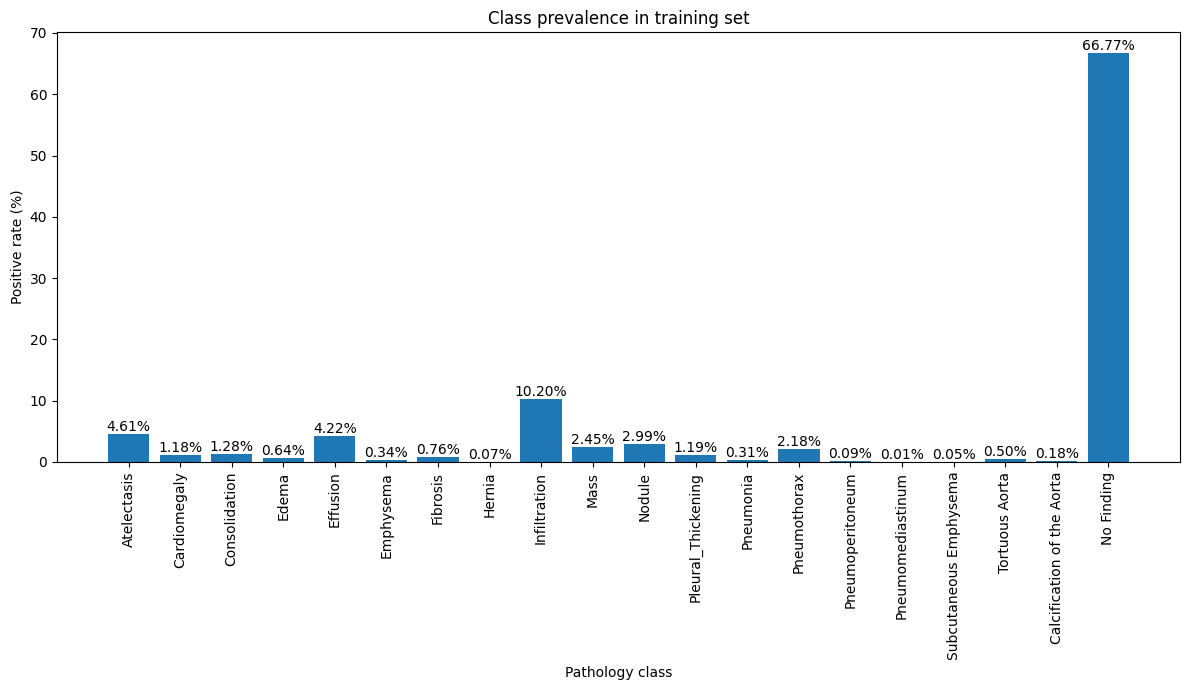

In [7]:
print(f"Train rows: {len(TrainCSV):,}")
print(f"Test rows: {len(TestCSV):,}")
plt.figure(figsize=(12, 7))
bars = plt.bar(ClassDist.index, ClassDist.values / len(TrainCSV) * 100)
plt.xlabel("Pathology class")
plt.ylabel("Positive rate (%)")
plt.bar_label(bars, fmt="%.2f%%")
plt.title("Class prevalence in training set")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [8]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=randSeed)
train_idx, val_idx = next(skf.split(TrainCSV, TrainCSV["label"]))
XTrain = TrainCSV.iloc[train_idx]
XVal   = TrainCSV.iloc[val_idx]
yTrain = XTrain["label"][train_idx]
yVal   = XVal["label"][val_idx]

print(f"Train split rows: {len(XTrain):,}")
print(f"Val split rows:   {len(XVal):,}")

Train split rows: 40,834
Val split rows:   10,209


In [9]:
imgSize= 224
ImgMean = [0.485, 0.456, 0.406]
ImgStd  = [0.229, 0.224, 0.225]

TrainTransform = transforms.Compose([
    transforms.Resize((imgSize + 32, imgSize + 32)),
    transforms.RandomCrop(imgSize),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=ImgMean, std=ImgStd),
])

EvalTransform = transforms.Compose([
    transforms.Resize((imgSize, imgSize)),
    transforms.ToTensor(),
    transforms.Normalize(mean=ImgMean, std=ImgStd),
])

In [10]:
class ChestXrayDataset(Dataset):
    def __init__(self, data, transform, labels=None):
        self.data      = data.reset_index(drop=True)
        self.Labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row   = self.data.iloc[idx]
        image = Image.open(row["ImgPath"]).convert("RGB")
        image_tensor = self.transform(image)

        if self.Labels is None:
            return image_tensor, row["id"]

        label = torch.tensor(row[self.Labels].values.astype(float),dtype=torch.float32)
        return image_tensor, label

In [11]:
batchSize= 32

TrainDataset = ChestXrayDataset(XTrain, labels=Labels, transform=TrainTransform)
ValDataset   = ChestXrayDataset(XVal,   labels=Labels, transform=EvalTransform)
TestDataset  = ChestXrayDataset(TestCSV, labels=None,  transform=EvalTransform)

TrainLoader = DataLoader(TrainDataset, batch_size=batchSize, num_workers=2, pin_memory=True)
ValLoader   = DataLoader(ValDataset, batch_size=batchSize * 2,shuffle=False, num_workers=2, pin_memory=True)
TestLoader  = DataLoader(TestDataset, batch_size=batchSize * 2,shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(TrainLoader)}")
print(f"Val batches:   {len(ValLoader)}")
print(f"Test batches:  {len(TestLoader)}")

Train batches: 1277
Val batches:   160
Test batches:  266


In [12]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score,accuracy_score
class XrayCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 8, 3, padding=1,bias=False),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 224 -> 112

            # Block 2
            nn.Dropout(0.5),
            nn.Conv2d(8, 16, 3, padding=1,bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 112 -> 56

            # Block 3
            nn.Dropout(0.5),
            nn.Conv2d(16, 32, 3, padding=1,bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 56 -> 28
            # Block 4
            nn.Dropout(0.5),
            nn.Conv2d(32, 64, 3, padding=1,bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 28 -> 14
            
            # Block 5
            nn.Dropout(0.5),
            nn.Conv2d(64, 128, 3, padding=1,bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 14 -> 7

            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
        )

        self.classifier = nn.Sequential(
            nn.BatchNorm1d(128),
            nn.Linear(128, 64,bias=False),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            
            nn.Dropout(0.5),
            nn.Linear(64, 32,bias=False),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.Dropout(0.2),
            nn.Linear(32, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [13]:
model = XrayCNN(num_classes=20).to(device)

In [14]:
ClassCounts = yTrain.value_counts().sort_index().to_numpy()
totalSamples = sum(ClassCounts)
ClassWeights = totalSamples / (len(Labels) * ClassCounts)
ClassWeights = torch.tensor(ClassWeights, dtype=torch.float32, device=device)
ClassWeights


tensor([1.0854e+00, 4.2535e+00, 3.9263e+00, 7.8226e+00, 1.1836e+00, 1.4903e+01,
        6.5650e+00, 6.8057e+01, 4.9020e-01, 2.0437e+00, 1.6722e+00, 4.1924e+00,
        1.5951e+01, 2.2915e+00, 5.8334e+01, 5.1042e+02, 1.0746e+02, 1.0008e+01,
        2.7968e+01, 7.4889e-02], device='cuda:0')

In [15]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4,weight_decay=1e-4)

AssymetricLoss = np.array([5]*19 + [1])
FinalWeights = ClassWeights * torch.tensor(AssymetricLoss, dtype=torch.float32, device=device)
LossFxn = nn.CrossEntropyLoss(weight=FinalWeights)

In [16]:
def CompScore(preds, targets, num_classes=20):
    score_c = []
    for c in range(num_classes):
        tp = ((preds == c) & (targets == c)).sum().item()
        fp = ((preds == c) & (targets != c)).sum().item()
        fn = ((preds != c) & (targets == c)).sum().item()
        nc = (targets == c).sum().item()
        if nc == 0:
            continue

        val = (tp - fp - 5 * fn) / nc
        score_c.append(val)

    if len(score_c) == 0:
        return 0.0

    return np.mean(score_c)

In [17]:
TrainLoss = []
ValidationLoss = []
TrainAcc = []
ValidationAcc = []
bestValAcc = 0.0
Compscore = -10000
patience = 5
patienceCounter = 0
Epoch = 0
TotalEpochs = 0

In [18]:
Epochs = 30
TotalEpochs += Epochs

TotalTrainBatches = len(TrainLoader)
TotalValBatches = len(ValLoader)
for epoch in range(Epochs):
    Epoch += 1
    print(f"Epoch [{Epoch}/{TotalEpochs}]:")

    model.train()
    trainLoss = 0.0
    trainCorrect = 0
    trainTotal = 0

    for batch_idx, (images, labels) in enumerate(TrainLoader):
        images = images.to(device)
        targets = labels.to(device)
        if targets.ndim > 1:
            targets = torch.argmax(targets, dim=1)
        targets = targets.long()
        outputs = model(images)

        loss = LossFxn(outputs, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        trainLoss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        trainCorrect += (preds == targets).sum().item()
        trainTotal += targets.size(0)

        print(f"Batch [{batch_idx}/{TotalTrainBatches}] Loss: {loss.item():.4f}", end="\r")

    avgTrainLoss = trainLoss / TotalTrainBatches
    trainAcc = trainCorrect / max(trainTotal, 1)

    model.eval()
    valLoss = 0.0

    val_preds_all = []
    val_targets_all = []

    with torch.no_grad():
        for images, labels in ValLoader:
            images = images.to(device)
            targets = labels.to(device)
            if targets.ndim > 1:
                targets = torch.argmax(targets, dim=1)
            targets = targets.long()
            outputs = model(images)

            loss = LossFxn(outputs, targets)
            valLoss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            val_preds_all.append(preds.cpu().numpy().ravel())
            val_targets_all.append(targets.cpu().numpy().ravel())

    val_preds_all = np.concatenate(val_preds_all).astype(np.int64)
    val_targets_all = np.concatenate(val_targets_all).astype(np.int64)
    f1 = f1_score(val_targets_all, val_preds_all, average='macro',zero_division=True)
    recall = recall_score(val_targets_all, val_preds_all, average='macro',zero_division=True)
    precision = precision_score(val_targets_all, val_preds_all, average='macro',zero_division=True)
    acc = accuracy_score(val_targets_all, val_preds_all)

    avgValLoss = valLoss / TotalValBatches
    currentCompScore = CompScore(torch.from_numpy(val_preds_all), torch.from_numpy(val_targets_all), num_classes=20)
    TrainLoss.append(avgTrainLoss)
    ValidationLoss.append(avgValLoss)
    TrainAcc.append(trainAcc)
    ValidationAcc.append(acc)

    print(f"Train Loss: {avgTrainLoss:.4f} | Train Acc: {trainAcc:.4f} | ")
    print(f"Val Loss: {avgValLoss:.4f} | Val Acc: {acc:.4f} | Comp Score: {currentCompScore:.4f}")
    print(f"f1:{f1}")
    print(f"recall:{recall}")
    print(f"precision:{precision}")
    if currentCompScore > Compscore:
        Compscore = currentCompScore
        torch.save(model.state_dict(), f"XrayCNN5{Epoch}.pth")
        print(f"Model saved (Comp Score: {currentCompScore:.4f})")
        patienceCounter = 0
    else:
        patienceCounter += 1
        if patienceCounter >= patience:
            print("Early stop point.")
    print("-" * 50)

Epoch [1/30]:
Train Loss: 2.9753 | Train Acc: 0.0384 | 
Val Loss: 2.9864 | Val Acc: 0.0459 | Comp Score: -5.7377
f1:0.004392208278703877
recall:0.0498936170212766
precision:0.9022972178683386
Model saved (Comp Score: -5.7377)
--------------------------------------------------
Epoch [2/30]:
Train Loss: 2.9145 | Train Acc: 0.0409 | 
Val Loss: 2.9861 | Val Acc: 0.0460 | Comp Score: -5.7361
f1:0.004401161157411742
recall:0.05
precision:0.9523018904887846
Model saved (Comp Score: -5.7361)
--------------------------------------------------
Epoch [3/30]:
Train Loss: 2.8899 | Train Acc: 0.0436 | 
Val Loss: 2.9474 | Val Acc: 0.0066 | Comp Score: -12.4824
f1:0.0010352574353196388
recall:0.0502127659574468
precision:0.9037675293001829
--------------------------------------------------
Epoch [4/30]:
Train Loss: 2.8694 | Train Acc: 0.0427 | 
Val Loss: 2.9929 | Val Acc: 0.0460 | Comp Score: -5.7361
f1:0.004401161157411742
recall:0.05
precision:0.9523018904887846
-------------------------------------

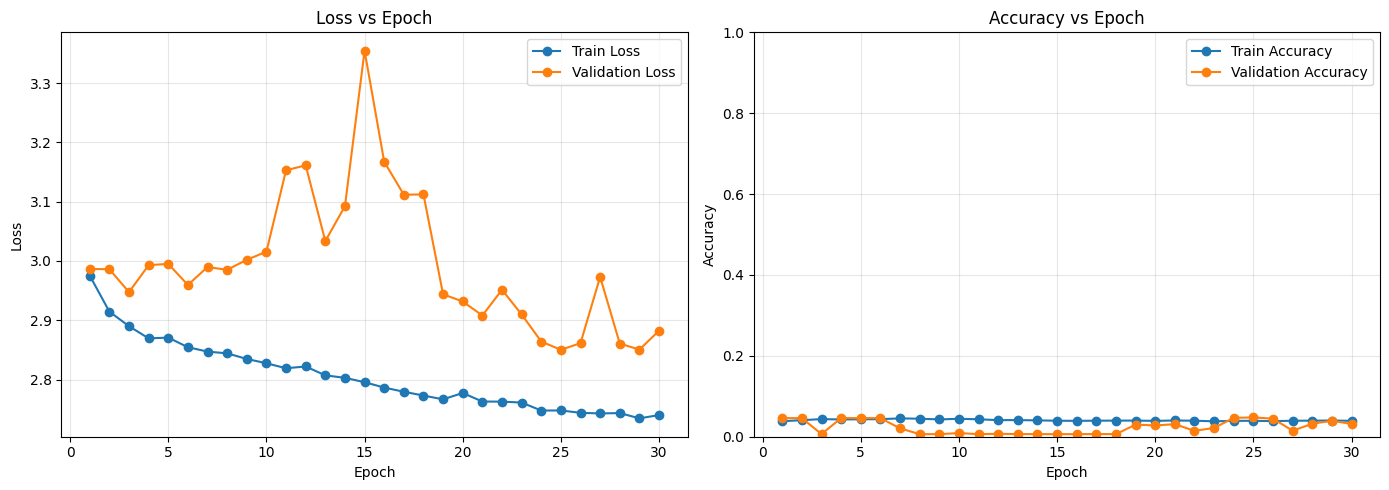

In [19]:
epochs = np.arange(1, len(TrainLoss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, TrainLoss, marker="o", label="Train Loss")
axes[0].plot(epochs, ValidationLoss, marker="o", label="Validation Loss")
axes[0].set_title("Loss vs Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)
axes[0].legend()

train_acc_series = TrainAcc
val_acc_series = ValidationAcc

axes[1].plot(epochs, train_acc_series, marker="o", label="Train Accuracy")
axes[1].plot(epochs, val_acc_series, marker="o", label="Validation Accuracy")
axes[1].set_title("Accuracy vs Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.0, 1.0)
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [20]:
model.eval()
predictions = []
test_ids = []

with torch.no_grad():
    for images, ids in TestLoader:
        images = images.to(device)
        outputs = model(images)
        batch_preds = torch.argmax(outputs, dim=1).cpu().numpy()
        predictions.extend(batch_preds.tolist())
        test_ids.extend(ids)

sample_cols = pd.read_csv("/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/sample_submission.csv", nrows=1).columns.tolist()

submission = pd.DataFrame({"id": test_ids})
for col in sample_cols[1:]:
    submission[col] = 0

for i, pred in enumerate(predictions):
    submission.iat[i, pred + 1] = 1

pred_counts = pd.Series(predictions).value_counts().sort_index()
print("Predicted class counts:")
print(pred_counts)

if len(pred_counts) == 1:
    only_cls = int(pred_counts.index[0])
    print(f"Warning: all predictions are class {only_cls} ({Labels[only_cls]}).")
    print("This is model collapse, not a CSV-generation bug.")

submission.to_csv("submission.csv", index=False)
print(f"Submission file created successfully with {len(submission)} rows.")
submission.head()

Predicted class counts:
0     5300
3     6953
5        3
8      349
9      835
10    3468
11       1
13     106
Name: count, dtype: int64
Submission file created successfully with 17015 rows.


,id,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,...,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax,Pneumoperitoneum,Pneumomediastinum,Subcutaneous Emphysema,Tortuous Aorta,Calcification of the Aorta,No Finding
0,7b647fbfcc874a7084a4470fc150e267.png,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1,cc804b94d80c4a80a206298c307adfec.png,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1df09c3becd04de995244caae36ddf57.png,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,044cac47cfdf4c8b90848c9e56c36bfa.png,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,a873523c43664a049c5e8f26add7ecb2.png,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
